In [1]:
print("hello")

hello


# Create a Linear Regression Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

In [4]:
california =  fetch_california_housing(as_frame=True)
print(california.DESCR)
X = california.data
y = california.target

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib:
https://lib.stat.cmu.edu/datasets/houses.zip

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block g

In [6]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [7]:
model = LinearRegression()
model.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.44, 0.01,-0.11,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-36.94
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


View coefficient and itercept


> coefficient : Positive means variables increase together; negative means one decreases as the other increases.Scale: Reflects the strength and impact of that specific independent variable.

> intercept: Definition: Represents the y-intercept of the regression line.Meaning: The predicted value of \(y\) when \(x\) is exactly zero.

In [10]:
coefficient = pd.Series(model.coef_, index=X.columns)
intercept = model.intercept_

print('intercept : ', intercept)
print('coefficient: ')
print(coefficient)

intercept :  -36.94192020718454
coefficient: 
MedInc        0.436693
HouseAge      0.009436
AveRooms     -0.107322
AveBedrms     0.645066
Population   -0.000004
AveOccup     -0.003787
Latitude     -0.421314
Longitude    -0.434514
dtype: float64


In [12]:
model.score(X,y)

0.606232685199805

generate predictions

In [13]:
prediction = model.predict(X)
result_df = pd.DataFrame({'Actual':y, 'predicted': prediction})
result_df.head()

,Actual,predicted
0,4.526,4.131650
1,3.585,3.976606
2,3.521,3.676571
3,3.413,3.241598
4,3.422,2.413587


Text(0, 0.5, 'Actual')

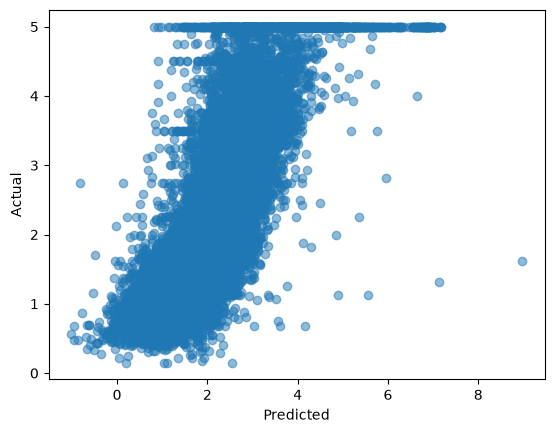

In [43]:
import matplotlib.pyplot as plt

plt.scatter(x=(result_df['predicted']), y = result_df['Actual'],alpha=0.5,label='prediction')
plt.xlabel('Predicted')
plt.ylabel('Actual')


In [44]:
# Calculate absolute error
result_df['error'] = (result_df['Actual'] - result_df['predicted']).abs()

In [45]:
# Find rows where the error is extremely large (e.g., greater than 5)
outliers = result_df[result_df['error'] > 5]
print(outliers)

       Actual  predicted     error
1979    1.625   8.970276  7.345276
18501   1.313   7.140618  5.827618
